# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
file_path = '/content/drive/MyDrive/Thesis Data/perishable_goods_management.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Set display options to ensure no columns are hidden
pd.set_option('display.max_columns', None)

# 1. Print the list of all column names
print("List of all columns in the dataset:")
print(df.columns.tolist())
print("\n" + "="*50 + "\n")

# 2. Display general information (row count, null values, data types)
print("General Information (Data Info):")
df.info()
print("\n" + "="*50 + "\n")

# 3. Preview the first 5 rows to understand the data structure
print("First 5 rows of the dataset:")
display(df.head())

List of all columns in the dataset:
['record_id', 'product_id', 'product_name', 'category', 'store_id', 'region', 'supplier_id', 'transaction_date', 'expiration_date', 'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation', 'base_price', 'cost_price', 'initial_quantity', 'spoilage_sensitivity', 'day_of_week', 'is_weekend', 'month', 'daily_demand', 'demand_variability', 'temp_abuse_events', 'distribution_hours', 'handling_score', 'packaging_score', 'spoilage_risk', 'was_spoiled', 'quality_grade', 'days_until_expiry', 'markdown_applied', 'discount_pct', 'selling_price', 'units_sold', 'units_wasted', 'waste_pct', 'revenue', 'waste_cost', 'profit', 'profit_margin_pct', 'supplier_score', 'is_promoted']


General Information (Data Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,is_weekend,month,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,spoilage_risk,was_spoiled,quality_grade,days_until_expiry,markdown_applied,discount_pct,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,2024-09-25,2024-09-29,4,4,21.0,1.0,2.60,1.22,158,0.50,2,0,9,54,0.35,0,41.5,9,10,0.099,0,A,2,0,0.00,2.60,138,20,12.7,358.80,24.40,166.04,46.3,9,0
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,2023-04-14,2023-04-21,9,7,0.7,0.3,8.25,4.18,353,0.90,4,0,4,55,0.35,0,38.7,8,8,0.172,0,A,4,0,0.00,8.25,251,102,28.9,2070.75,426.36,595.21,28.7,6,0
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,2024-10-25,2024-10-27,2,2,21.3,1.3,4.12,2.12,483,0.50,4,0,10,331,0.35,0,54.1,4,8,0.201,0,B,0,1,0.69,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6,9,0
3,4,PHA_VAC_801,Vaccines,Pharmaceuticals,STORE_003,Midwest,SUPPLIER_11,2023-11-29,2024-02-17,87,80,8.0,3.0,209.56,87.99,477,0.85,2,0,11,7,0.38,0,70.1,5,9,0.230,0,B,79,0,0.00,209.56,477,0,0.0,99960.12,0.00,57988.89,58.0,6,0
4,5,REA_FRE_422,Fresh Pasta,Ready_to_Eat,STORE_042,West,SUPPLIER_15,2023-08-06,2023-08-09,4,3,3.5,0.5,6.86,3.03,391,0.90,6,1,8,169,0.25,0,64.9,5,6,0.268,0,C,3,1,0.23,5.28,391,0,0.0,2064.48,0.00,879.75,42.6,6,0


In [3]:
# Filter out irrelevant categories (Pharmaceuticals and Frozen Meals)
categories_to_remove = ['Pharmaceuticals', 'Frozen_Meals']
df_cleaned = df[~df['category'].isin(categories_to_remove)].copy()

In [4]:
columns_to_drop = [
    'region', 'supplier_id', 'temp_deviation', 'spoilage_sensitivity',
    'day_of_week', 'is_weekend', 'month', 'temp_abuse_events',
    'packaging_score', 'quality_grade', 'supplier_score', 'is_promoted','handling_score', 'spoilage_risk','index', 'record_id', 'store_id', 'product_id',
    'storage_temp', 'distribution_hours',
    'transaction_date', 'expiration_date'
]

In [5]:
# Execute the drop function
df_cleaned = df_cleaned.drop(columns=columns_to_drop, errors='ignore')

# Display the cleaning results
print("Data Cleaning Completed Successfully!\n")
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")
print("\n" + "="*50)
print("List of remaining columns for Financial Simulation:")
print(df_cleaned.columns.tolist())

Data Cleaning Completed Successfully!

Original dataset shape: (100000, 42)
Cleaned dataset shape: (79957, 21)

List of remaining columns for Financial Simulation:
['product_name', 'category', 'shelf_life_days', 'days_remaining_at_purchase', 'base_price', 'cost_price', 'initial_quantity', 'daily_demand', 'demand_variability', 'was_spoiled', 'days_until_expiry', 'markdown_applied', 'discount_pct', 'selling_price', 'units_sold', 'units_wasted', 'waste_pct', 'revenue', 'waste_cost', 'profit', 'profit_margin_pct']


In [6]:
# Display the first 10 rows of the cleaned DataFrame to verify the structure
print("Preview of the first 10 rows (Cleaned Data):")
display(df_cleaned.head(10))

Preview of the first 10 rows (Cleaned Data):


,product_name,category,shelf_life_days,days_remaining_at_purchase,base_price,cost_price,initial_quantity,daily_demand,demand_variability,was_spoiled,days_until_expiry,markdown_applied,discount_pct,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct
0,Donuts,Bakery,4,4,2.60,1.22,158,54,0.35,0,2,0,0.00,2.60,138,20,12.7,358.80,24.40,166.04,46.3
1,Sausages,Meat,9,7,8.25,4.18,353,55,0.35,0,4,0,0.00,8.25,251,102,28.9,2070.75,426.36,595.21,28.7
2,Bagels,Bakery,2,2,4.12,2.12,483,331,0.35,0,0,1,0.69,1.28,483,0,0.0,618.24,0.00,-405.72,-65.6
4,Fresh Pasta,Ready_to_Eat,4,3,6.86,3.03,391,169,0.25,0,3,1,0.23,5.28,391,0,0.0,2064.48,0.00,879.75,42.6
6,Fresh Juice,Beverages,10,9,8.34,4.39,42,4,0.40,0,8,0,0.00,8.34,41,1,2.4,341.94,4.39,157.56,46.1
9,Croissants,Bakery,6,6,12.94,7.15,111,50,0.12,0,5,0,0.00,12.94,111,0,0.0,1436.34,0.00,642.69,44.7
10,Tuna,Seafood,6,4,19.99,8.11,485,116,0.23,0,3,0,0.00,19.99,257,228,47.0,5137.43,1849.08,1204.08,23.4
11,Salami,Deli,6,4,14.25,9.19,399,103,0.30,1,4,0,0.00,14.25,279,120,30.1,3975.75,1102.80,308.94,7.8
14,Tomatoes,Produce,3,3,1.05,0.64,40,16,0.46,0,3,1,0.19,0.85,40,0,0.0,34.00,0.00,8.40,24.7
15,Lettuce,Produce,5,5,2.50,1.10,488,130,0.24,0,4,0,0.00,2.50,488,0,0.0,1220.00,0.00,683.20,56.0


In [7]:
# ==========================================
# DATA PREPROCESSING: SHELF-LIFE TRUNCATION
# ==========================================
print("--- DATA FILTERING STAGE ---")

# 1. Evaluate initial dataset size
initial_count = len(df_cleaned)

# 2. Apply exclusion criterion: Drop items with shelf_life_days > 15
df_filtered = df_cleaned[df_cleaned['shelf_life_days'] <= 10].copy()
filtered_count = len(df_filtered)
excluded_count = initial_count - filtered_count

print(f"Initial Dataset Size: {initial_count:,} transactions")
print(f"Records Excluded (Shelf Life > 10 days): {excluded_count:,} transactions")
print(f"Refined Dataset Size: {filtered_count:,} transactions\n")

# Verify category distribution after filtering
print("--- CATEGORY DISTRIBUTION (PERISHABLE F&B SUBSET) ---")
print(df_filtered['category'].value_counts())

# Verify descriptive statistics
key_variables = ['shelf_life_days', 'days_remaining_at_purchase',
                 'cost_price', 'base_price', 'initial_quantity', 'daily_demand']
print("\n--- DESCRIPTIVE STATISTICS (FILTERED DATASET) ---")
display(df_filtered[key_variables].describe().T[['mean', 'std', 'min', 'max']].round(2))

--- DATA FILTERING STAGE ---
Initial Dataset Size: 79,957 transactions
Records Excluded (Shelf Life > 10 days): 25,181 transactions
Refined Dataset Size: 54,776 transactions

--- CATEGORY DISTRIBUTION (PERISHABLE F&B SUBSET) ---
category
Meat            10055
Ready_to_Eat    10049
Bakery          10039
Seafood          9957
Deli             6567
Produce          4203
Dairy            2274
Beverages        1632
Name: count, dtype: int64

--- DESCRIPTIVE STATISTICS (FILTERED DATASET) ---


,mean,std,min,max
shelf_life_days,5.23,2.41,1.00,10.00
days_remaining_at_purchase,4.46,2.22,0.00,10.00
cost_price,7.37,5.19,0.41,31.43
base_price,13.39,9.07,1.00,45.00
initial_quantity,254.95,141.87,10.00,500.00
daily_demand,106.46,108.41,0.00,1118.00


In [8]:
key_variables = ['shelf_life_days', 'days_remaining_at_purchase', 'cost_price', 'base_price', 'initial_quantity', 'daily_demand']

descriptive_table = df_filtered[key_variables].describe().T[['mean', 'std', 'min', 'max']]
descriptive_table.columns = ['Mean', 'Std. Deviation', 'Minimum', 'Maximum']
descriptive_table.index = ['Total Shelf Life (Days)', 'Days Remaining at Purchase', 'Cost Price ($)', 'Base Price ($)', 'Initial Quantity (Units)', 'Daily Demand (Units)']

print("--- TABLE 3.1: DESCRIPTIVE STATISTICS ---")
display(descriptive_table.round(2))

--- TABLE 3.1: DESCRIPTIVE STATISTICS ---


,Mean,Std. Deviation,Minimum,Maximum
Total Shelf Life (Days),5.23,2.41,1.00,10.00
Days Remaining at Purchase,4.46,2.22,0.00,10.00
Cost Price ($),7.37,5.19,0.41,31.43
Base Price ($),13.39,9.07,1.00,45.00
Initial Quantity (Units),254.95,141.87,10.00,500.00
Daily Demand (Units),106.46,108.41,0.00,1118.00


# Data Simulation



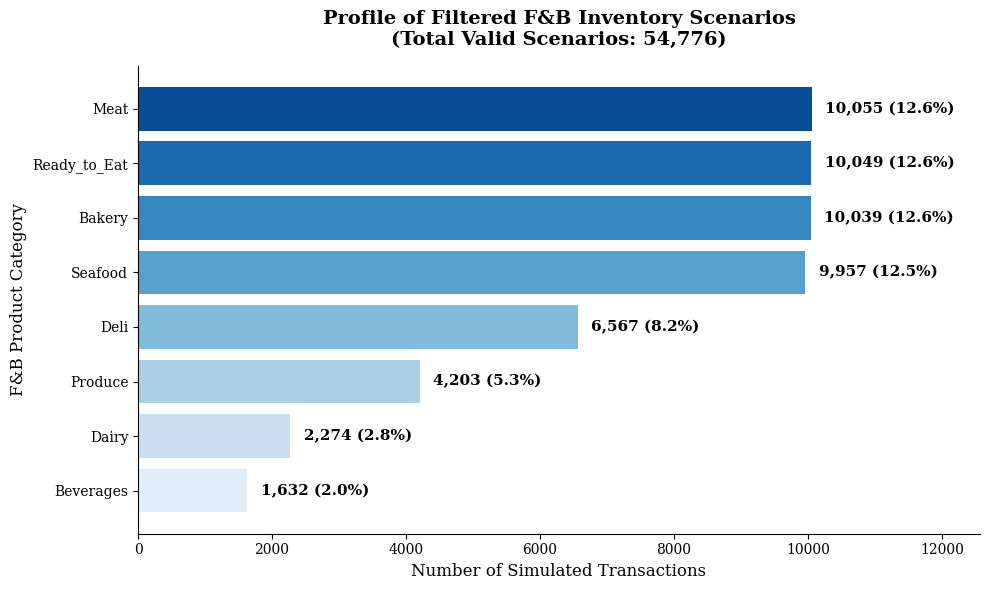

--- DATASET PROFILE SUMMARY ---
Total Rows After Cleaning: 79957
category
Meat            10055
Ready_to_Eat    10049
Bakery          10039
Seafood          9957
Deli             6567
Produce          4203
Dairy            2274
Beverages        1632
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style for academic standards
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'

# 1. Calculate category counts from your cleaned dataset (df_cleaned)
category_counts = df_filtered['category'].value_counts()
category_percentages = (category_counts / len(df_cleaned)) * 100

# 2. Draw a horizontal bar chart
colors = sns.color_palette("Blues_r", len(category_counts))
bars = plt.barh(category_counts.index, category_counts.values, color=colors)

# 3. Add data labels (Quantity and Percentage)
for bar, pct in zip(bars, category_percentages):
    width = bar.get_width()
    plt.text(width + (max(category_counts.values) * 0.02),
             bar.get_y() + bar.get_height()/2,
             f'{int(width):,} ({pct:.1f}%)',
             va='center', ha='left', fontsize=11, color='black', fontweight='bold')

# 4. Format the chart titles and axes
plt.title(f"Profile of Filtered F&B Inventory Scenarios\n(Total Valid Scenarios: {len(df_filtered):,})",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Simulated Transactions", fontsize=12)
plt.ylabel("F&B Product Category", fontsize=12)

# Expand x-axis slightly to fit the text labels
plt.xlim(0, max(category_counts.values) * 1.25)
plt.gca().invert_yaxis() # Put the largest category on top

# 5. Clean up borders and save
sns.despine()
plt.tight_layout()
plt.savefig('Dataset_Profile_Chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Print out the exact numbers for your reference
print("--- DATASET PROFILE SUMMARY ---")
print(f"Total Rows After Cleaning: {len(df_cleaned)}")
print(category_counts)

--- BASELINE SIMULATION RESULTS (STATIC PRICING) ---
Total Scenarios Evaluated: 27,388
Average Waste Percentage: 36.23%
Total Revenue Generated: $61,716,478.14
Total Cost of Overage (Waste Cost): $17,386,214.99
Average Net Profit: $380.02


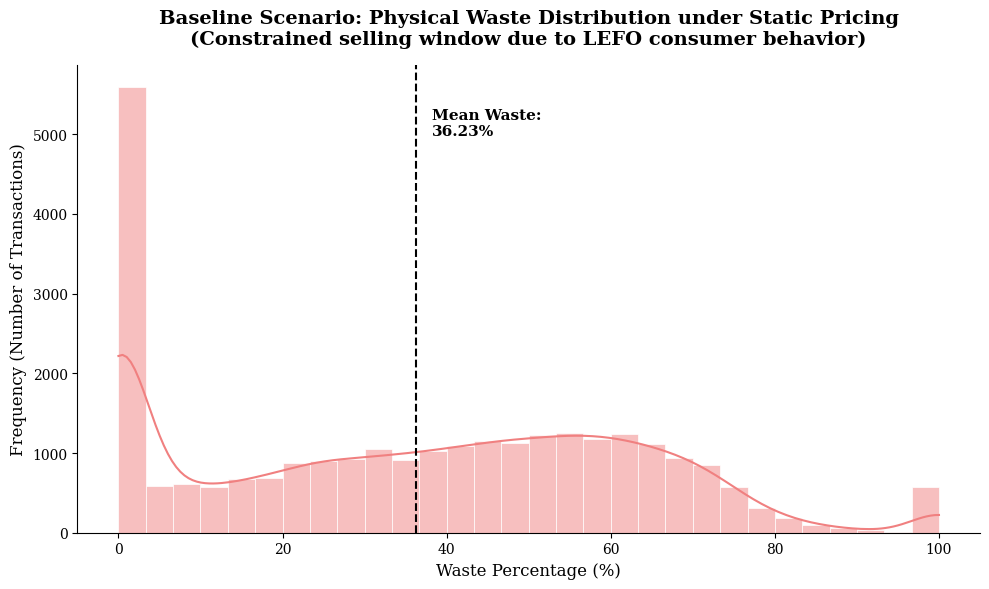

In [10]:
# ==========================================
# SECTION 3.1.2: BASELINE SCENARIO (STATIC PRICING)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate 50% of the dataset for the Baseline Control Group
df_baseline = df_filtered.sample(frac=0.5, random_state=2026).copy()

# 2. STATIC PRICING LOGIC
# Price remains fixed at base price throughout the entire shelf-life
df_baseline['simulated_price'] = df_baseline['base_price']

# 3. CONSTRAINED EFFECTIVE SELLING WINDOW
# Under static pricing, age-sensitive consumers exhibit Last-Expired-First-Out
# (LEFO) behavior, actively bypassing aging inventory in favor of fresher units.
# This behavioral constraint effectively restricts the merchant's commercial
# selling window to the first 2 days of display, regardless of physical shelf-life.
# Reference: Riesenegger & Hubner (2026); Teller et al. (2018)
STATIC_SELLING_WINDOW = 2

# 4. CUMULATIVE DEMAND UNDER STATIC POLICY
df_baseline['effective_days'] = np.minimum(
    df_baseline['days_remaining_at_purchase'],
    STATIC_SELLING_WINDOW
)
df_baseline['total_demand'] = df_baseline['daily_demand'] * df_baseline['effective_days']

# 5. KESKIN'S DETERMINISTIC INVENTORY CONSTRAINT
df_baseline['units_sold'] = np.minimum(
    df_baseline['initial_quantity'],
    df_baseline['total_demand']
)

# 6. PHYSICAL WASTE CALCULATION
df_baseline['units_wasted'] = df_baseline['initial_quantity'] - df_baseline['units_sold']
df_baseline['waste_pct'] = (df_baseline['units_wasted'] / df_baseline['initial_quantity']) * 100

# 7. FINANCIAL CALCULATIONS (Sunk Cost and Cost of Overage)
df_baseline['sunk_cost'] = df_baseline['initial_quantity'] * df_baseline['cost_price']
df_baseline['revenue'] = df_baseline['units_sold'] * df_baseline['simulated_price']
df_baseline['waste_cost'] = df_baseline['units_wasted'] * df_baseline['cost_price']
df_baseline['net_profit'] = df_baseline['revenue'] - df_baseline['sunk_cost']

# 8. OUTPUT RESULTS FOR SECTION 3.1.2
print("--- BASELINE SIMULATION RESULTS (STATIC PRICING) ---")
print(f"Total Scenarios Evaluated: {len(df_baseline):,}")
print(f"Average Waste Percentage: {df_baseline['waste_pct'].mean():.2f}%")
print(f"Total Revenue Generated: ${df_baseline['revenue'].sum():,.2f}")
print(f"Total Cost of Overage (Waste Cost): ${df_baseline['waste_cost'].sum():,.2f}")
print(f"Average Net Profit: ${df_baseline['net_profit'].mean():.2f}")

# 9. VISUALIZATION: WASTE DISTRIBUTION UNDER STATIC PRICING
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'

sns.histplot(df_baseline['waste_pct'], bins=30, color='lightcoral',
             edgecolor='white', linewidth=0.5, stat="count", kde=True)

mean_waste = df_baseline['waste_pct'].mean()
plt.axvline(mean_waste, color='black', linestyle='--', linewidth=1.5)
plt.text(mean_waste + 2, plt.ylim()[1] * 0.85,
         f'Mean Waste:\n{mean_waste:.2f}%',
         fontsize=11, fontweight='bold')

plt.title("Baseline Scenario: Physical Waste Distribution under Static Pricing\n"
          "(Constrained selling window due to LEFO consumer behavior)",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Waste Percentage (%)", fontsize=12)
plt.ylabel("Frequency (Number of Transactions)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('Figure_3_1_2_Static_Waste.png', dpi=300, bbox_inches='tight')
plt.show()

--- INTERVENTION SIMULATION RESULTS (DYNAMIC PRICING) ---
Total Scenarios Evaluated: 27,388
Average Waste Percentage: 4.19%
Total Revenue Generated: $90,342,213.86
Total Cost of Overage (Waste Cost): $1,324,537.10
Average Net Profit: $1414.88

--- COMPARATIVE PERFORMANCE (Static vs. Dynamic) ---
Waste Reduction: 32.04 percentage points
Profit Recovery per Transaction: $1034.86
Total Waste Cost Savings: $16,061,677.89


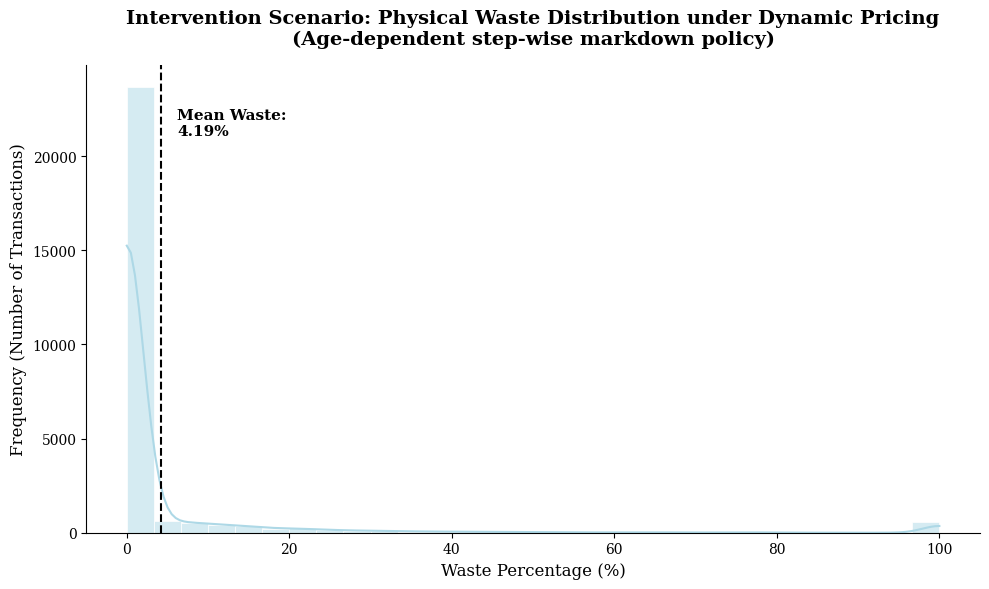

In [11]:
# ==========================================
# SECTION 3.1.3: INTERVENTION SCENARIO (DYNAMIC PRICING)
# ==========================================
df_intervention = df_filtered.drop(df_baseline.index).copy()

# 1. CALCULATE REMAINING LIFECYCLE RATIO
# Age-dependent threshold policy following Fadda et al. (2024)
# Ratio measures the proportion of shelf-life remaining at the point of decision
df_intervention['lifecycle_ratio'] = (
    df_intervention['days_remaining_at_purchase']
    / df_intervention['shelf_life_days']
)

# 2. RULE-BASED STEP-WISE MARKDOWN LOGIC (Age-Dependent)
# Two-tier deterministic markdown policy:
# Tier 1 (early signal): 20% markdown when product has consumed 50% of shelf-life
# Tier 2 (aggressive clearance): 40% markdown when product has consumed 80% of shelf-life
def assign_discount_by_ratio(ratio):
    if ratio <= 0.20:
        return 0.40
    elif ratio <= 0.50:
        return 0.20
    else:
        return 0.00

df_intervention['discount_pct'] = df_intervention['lifecycle_ratio'].apply(assign_discount_by_ratio)
df_intervention['simulated_price'] = df_intervention['base_price'] * (1 - df_intervention['discount_pct'])

# 3. PRICE ELASTICITY OF DEMAND
# Clearance pricing elasticity for perishable F&B calibrated to empirical literature
# Reference: Wang & Li (2012); Tsiros & Heilman (2005); Fadda et al. (2024)
PRICE_ELASTICITY = 3.0

df_intervention['demand_multiplier'] = 1 + (df_intervention['discount_pct'] * PRICE_ELASTICITY)

# 4. EXTENDED EFFECTIVE SELLING WINDOW
# Under dynamic pricing, markdowns mathematically convert age-sensitive shoppers
# into price-sensitive buyers, effectively eliminating the LEFO behavioral
# constraint. This expansion allows the merchant to capture demand throughout
# the full remaining shelf-life rather than the restricted 2-day window.
# Reference: Riesenegger & Hubner (2026)
df_intervention['effective_days'] = df_intervention['days_remaining_at_purchase']
df_intervention['total_demand'] = (
    df_intervention['daily_demand']
    * df_intervention['effective_days']
    * df_intervention['demand_multiplier']
)

# 5. KESKIN'S DETERMINISTIC INVENTORY CONSTRAINT
df_intervention['units_sold'] = np.minimum(
    df_intervention['initial_quantity'],
    df_intervention['total_demand']
)

# 6. PHYSICAL WASTE CALCULATION
df_intervention['units_wasted'] = df_intervention['initial_quantity'] - df_intervention['units_sold']
df_intervention['waste_pct'] = (df_intervention['units_wasted'] / df_intervention['initial_quantity']) * 100

# 7. FINANCIAL CALCULATIONS
df_intervention['sunk_cost'] = df_intervention['initial_quantity'] * df_intervention['cost_price']
df_intervention['revenue'] = df_intervention['units_sold'] * df_intervention['simulated_price']
df_intervention['waste_cost'] = df_intervention['units_wasted'] * df_intervention['cost_price']
df_intervention['net_profit'] = df_intervention['revenue'] - df_intervention['sunk_cost']

# 8. OUTPUT RESULTS FOR SECTION 3.1.3
print("--- INTERVENTION SIMULATION RESULTS (DYNAMIC PRICING) ---")
print(f"Total Scenarios Evaluated: {len(df_intervention):,}")
print(f"Average Waste Percentage: {df_intervention['waste_pct'].mean():.2f}%")
print(f"Total Revenue Generated: ${df_intervention['revenue'].sum():,.2f}")
print(f"Total Cost of Overage (Waste Cost): ${df_intervention['waste_cost'].sum():,.2f}")
print(f"Average Net Profit: ${df_intervention['net_profit'].mean():.2f}")

# 9. COMPARATIVE PERFORMANCE METRICS
waste_reduction = df_baseline['waste_pct'].mean() - df_intervention['waste_pct'].mean()
profit_delta = df_intervention['net_profit'].mean() - df_baseline['net_profit'].mean()
waste_cost_savings = df_baseline['waste_cost'].sum() - df_intervention['waste_cost'].sum()

print(f"\n--- COMPARATIVE PERFORMANCE (Static vs. Dynamic) ---")
print(f"Waste Reduction: {waste_reduction:.2f} percentage points")
print(f"Profit Recovery per Transaction: ${profit_delta:.2f}")
print(f"Total Waste Cost Savings: ${waste_cost_savings:,.2f}")

# 10. VISUALIZATION: WASTE DISTRIBUTION UNDER DYNAMIC PRICING
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'

sns.histplot(df_intervention['waste_pct'], bins=30, color='lightblue',
             edgecolor='white', linewidth=0.5, stat="count", kde=True)

mean_waste_int = df_intervention['waste_pct'].mean()
plt.axvline(mean_waste_int, color='black', linestyle='--', linewidth=1.5)
plt.text(mean_waste_int + 2, plt.ylim()[1] * 0.85,
         f'Mean Waste:\n{mean_waste_int:.2f}%',
         fontsize=11, fontweight='bold')

plt.title("Intervention Scenario: Physical Waste Distribution under Dynamic Pricing\n"
          "(Age-dependent step-wise markdown policy)",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Waste Percentage (%)", fontsize=12)
plt.ylabel("Frequency (Number of Transactions)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('Figure_3_1_3_Dynamic_Waste.png', dpi=300, bbox_inches='tight')
plt.show()

--- TABLE 3.1.5: CATEGORY-LEVEL PERFORMANCE COMPARISON ---

    category  Sample_Size  Waste_Static  Waste_Dynamic  Waste_Reduction_pp  Profit_Static  Profit_Dynamic  Profit_Delta
     Seafood         4945         29.24           2.01               27.24        1116.31         2865.65       1749.35
        Meat         5052         45.27           3.01               42.26          36.33         1676.28       1639.95
        Deli         3300         45.63           3.01               42.63           5.80         1233.68       1227.88
       Dairy         1132         55.43           3.73               51.70        -175.18          786.87        962.05
   Beverages          793         64.73           6.29               58.44        -291.70          635.09        926.79
      Bakery         5059         26.52           1.45               25.06         410.78          925.07        514.29
     Produce         2115         46.33           4.35               41.98          -6.57          4

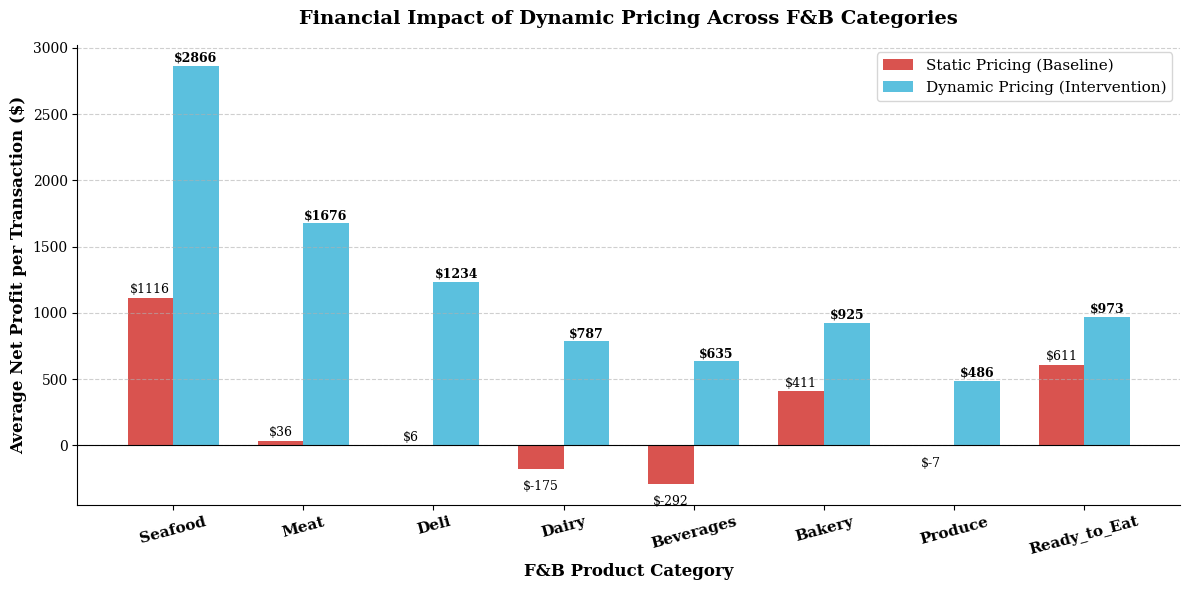

In [12]:
# ==========================================
# SECTION 3.1.4: CATEGORY-LEVEL COMPARATIVE ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. AGGREGATE STATIC PRICING METRICS BY CATEGORY
base_grouped = df_baseline.groupby('category').agg(
    Sample_Size=('waste_pct', 'count'),
    Waste_Static=('waste_pct', 'mean'),
    Revenue_Static=('revenue', 'sum'),
    WasteCost_Static=('waste_cost', 'sum'),
    Profit_Static=('net_profit', 'mean')
).reset_index()

# 2. AGGREGATE DYNAMIC PRICING METRICS BY CATEGORY
int_grouped = df_intervention.groupby('category').agg(
    Waste_Dynamic=('waste_pct', 'mean'),
    Revenue_Dynamic=('revenue', 'sum'),
    WasteCost_Dynamic=('waste_cost', 'sum'),
    Profit_Dynamic=('net_profit', 'mean'),
    Avg_Discount=('discount_pct', 'mean')
).reset_index()

# 3. MERGE DATAFRAMES AND COMPUTE PERFORMANCE DELTAS
df_compare = pd.merge(base_grouped, int_grouped, on='category')
df_compare['Waste_Reduction_pp'] = df_compare['Waste_Static'] - df_compare['Waste_Dynamic']
df_compare['Profit_Delta'] = df_compare['Profit_Dynamic'] - df_compare['Profit_Static']
df_compare['Profit_Growth_Pct'] = (
    (df_compare['Profit_Dynamic'] - df_compare['Profit_Static'])
    / df_compare['Profit_Static'].abs()
) * 100

# 4. SORT BY PROFIT DELTA FOR NARRATIVE CLARITY
df_compare = df_compare.sort_values('Profit_Delta', ascending=False).reset_index(drop=True)

# 5. OUTPUT COMPREHENSIVE COMPARISON TABLE
print("--- TABLE 3.1.5: CATEGORY-LEVEL PERFORMANCE COMPARISON ---\n")
display_cols = ['category', 'Sample_Size', 'Waste_Static', 'Waste_Dynamic',
                'Waste_Reduction_pp', 'Profit_Static', 'Profit_Dynamic', 'Profit_Delta']
print(df_compare[display_cols].to_string(index=False, float_format="%.2f"))

print("\n--- AVERAGE MARKDOWN DEPLOYED BY CATEGORY ---")
print(df_compare[['category', 'Avg_Discount']].to_string(index=False, float_format="%.4f"))

# 6. VISUALIZATION: GROUPED BAR CHART - NET PROFIT COMPARISON
plt.rcParams['font.family'] = 'serif'

x = np.arange(len(df_compare['category']))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, df_compare['Profit_Static'], width,
                label='Static Pricing (Baseline)', color='#d9534f', edgecolor='none')
rects2 = ax.bar(x + width/2, df_compare['Profit_Dynamic'], width,
                label='Dynamic Pricing (Intervention)', color='#5bc0de', edgecolor='none')

# Add value labels on top of bars
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'${height:.0f}',
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3 if height >= 0 else -15),
                textcoords="offset points",
                ha='center', fontsize=9)
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'${height:.0f}',
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3 if height >= 0 else -15),
                textcoords="offset points",
                ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Average Net Profit per Transaction ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('F&B Product Category', fontsize=12, fontweight='bold')
ax.set_title('Financial Impact of Dynamic Pricing Across F&B Categories',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_compare['category'], fontsize=11, fontweight='bold', rotation=15)
ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='best', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('Figure_3_1_4_Category_Profit.png', dpi=300, bbox_inches='tight')
plt.show()

--- EXECUTING SENSITIVITY ANALYSIS GRID SEARCH ---
Total configurations evaluated: 45

--- PROFIT DELTA MATRIX (Dynamic - Static) ($) ---
Tier 1 Lifecycle Threshold      30%      35%      40%      45%      50%      55%      60%      65%      70%
Static Selling Window                                                                                      
1 day(s)                    1967.93  1967.93  1967.93  1967.93  1967.17  1967.17  1967.17  1967.17  1890.30
2 day(s)                    1035.62  1035.62  1035.62  1035.62  1034.86  1034.86  1034.86  1034.86   957.99
3 day(s)                     492.57   492.57   492.57   492.57   491.80   491.80   491.80   491.80   414.94
4 day(s)                     211.68   211.68   211.68   211.68   210.92   210.92   210.92   210.92   134.05
5 day(s)                      87.28    87.28    87.28    87.28    86.52    86.52    86.52    86.52     9.65

--- DYNAMIC PRICING NET PROFIT MATRIX ($) ---
              30%      35%      40%      45%      50%      

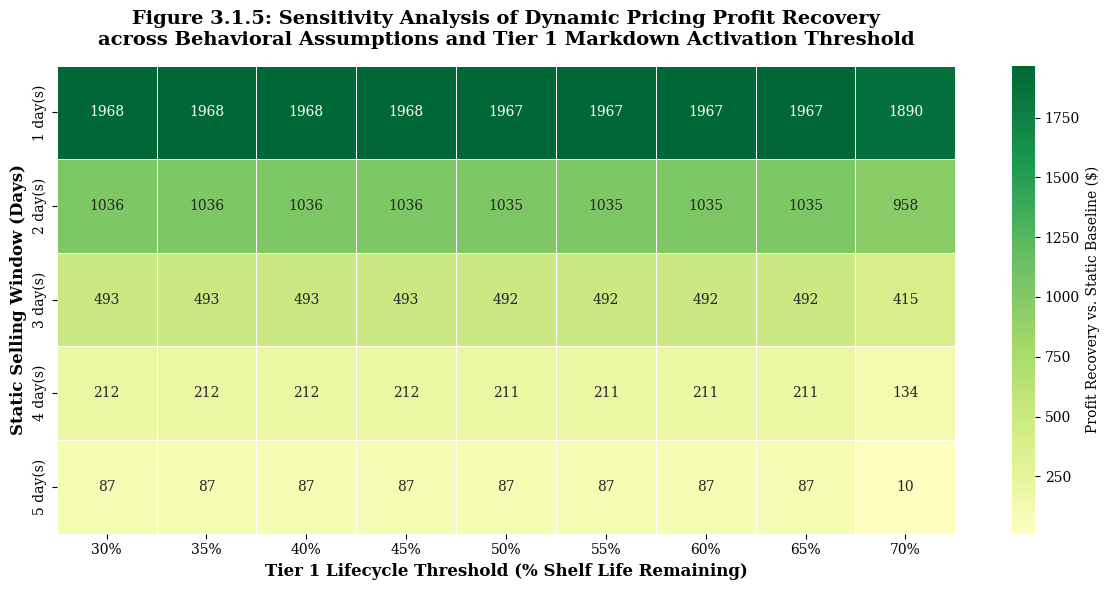

In [13]:
# ==========================================
# SECTION 3.1.5: SENSITIVITY ANALYSIS (ROBUSTNESS CHECK)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. DEFINE PARAMETER GRID FOR SENSITIVITY TESTING
# Static Selling Window: behavioral parameter modeling LEFO consumer constraint
# Tested range covers conservative (1 day) to optimistic (5 days) assumptions
selling_windows = [1, 2, 3, 4, 5]

# Tier 1 Lifecycle Threshold: policy parameter controlling when early markdown activates
# Tested range covers conservative late activation (30%) to aggressive early activation (70%)
tier1_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

# 2. INITIALIZE RESULTS MATRICES
profit_dynamic_matrix = np.zeros((len(selling_windows), len(tier1_thresholds)))
profit_static_matrix = np.zeros((len(selling_windows), len(tier1_thresholds)))
profit_delta_matrix = np.zeros((len(selling_windows), len(tier1_thresholds)))

# 3. FIXED PARAMETERS (from main simulation)
FIXED_ELASTICITY = 3.0
FIXED_TIER2_THRESHOLD = 0.20
FIXED_TIER1_DISCOUNT = 0.20
FIXED_TIER2_DISCOUNT = 0.40

# 4. GRID SEARCH ITERATION
print("--- EXECUTING SENSITIVITY ANALYSIS GRID SEARCH ---")
print(f"Total configurations evaluated: {len(selling_windows) * len(tier1_thresholds)}")

for i, window in enumerate(selling_windows):
    # Recalculate Static baseline for this selling window
    temp_static = df_baseline.copy()
    temp_static['effective_days'] = np.minimum(
        temp_static['days_remaining_at_purchase'], window
    )
    temp_static['total_demand'] = temp_static['daily_demand'] * temp_static['effective_days']
    temp_static['units_sold'] = np.minimum(
        temp_static['initial_quantity'], temp_static['total_demand']
    )
    temp_static['revenue'] = temp_static['units_sold'] * temp_static['base_price']
    temp_static['sunk_cost'] = temp_static['initial_quantity'] * temp_static['cost_price']
    static_profit = (temp_static['revenue'] - temp_static['sunk_cost']).mean()

    for j, tier1_thresh in enumerate(tier1_thresholds):
        # Apply dynamic pricing with variable tier 1 threshold
        temp_df = df_filtered.drop(df_baseline.index).copy()
        temp_df['lifecycle_ratio'] = (
            temp_df['days_remaining_at_purchase'] / temp_df['shelf_life_days']
        )

        def assign_discount(ratio, t1_thresh):
            if ratio <= FIXED_TIER2_THRESHOLD:
                return FIXED_TIER2_DISCOUNT
            elif ratio <= t1_thresh:
                return FIXED_TIER1_DISCOUNT
            else:
                return 0.00

        temp_df['discount_pct'] = temp_df['lifecycle_ratio'].apply(
            lambda r: assign_discount(r, tier1_thresh)
        )
        temp_df['simulated_price'] = temp_df['base_price'] * (1 - temp_df['discount_pct'])
        temp_df['demand_multiplier'] = 1 + (temp_df['discount_pct'] * FIXED_ELASTICITY)
        temp_df['effective_days'] = temp_df['days_remaining_at_purchase']
        temp_df['total_demand'] = (
            temp_df['daily_demand']
            * temp_df['effective_days']
            * temp_df['demand_multiplier']
        )
        temp_df['units_sold'] = np.minimum(
            temp_df['initial_quantity'], temp_df['total_demand']
        )
        temp_df['revenue'] = temp_df['units_sold'] * temp_df['simulated_price']
        temp_df['sunk_cost'] = temp_df['initial_quantity'] * temp_df['cost_price']
        dynamic_profit = (temp_df['revenue'] - temp_df['sunk_cost']).mean()

        profit_dynamic_matrix[i, j] = dynamic_profit
        profit_static_matrix[i, j] = static_profit
        profit_delta_matrix[i, j] = dynamic_profit - static_profit

# 5. CONVERT MATRICES TO DATAFRAMES FOR DISPLAY
delta_df = pd.DataFrame(
    profit_delta_matrix,
    index=[f'{w} day(s)' for w in selling_windows],
    columns=[f'{int(t*100)}%' for t in tier1_thresholds]
)
delta_df.index.name = 'Static Selling Window'
delta_df.columns.name = 'Tier 1 Lifecycle Threshold'

dynamic_df = pd.DataFrame(
    profit_dynamic_matrix,
    index=[f'{w} day(s)' for w in selling_windows],
    columns=[f'{int(t*100)}%' for t in tier1_thresholds]
)

print("\n--- PROFIT DELTA MATRIX (Dynamic - Static) ($) ---")
print(delta_df.round(2).to_string())

print("\n--- DYNAMIC PRICING NET PROFIT MATRIX ($) ---")
print(dynamic_df.round(2).to_string())

# 6. IDENTIFY OPTIMAL CONFIGURATION
max_delta = profit_delta_matrix.max()
max_idx = np.unravel_index(profit_delta_matrix.argmax(), profit_delta_matrix.shape)
optimal_window = selling_windows[max_idx[0]]
optimal_threshold = tier1_thresholds[max_idx[1]]

print(f"\n--- OPTIMAL CONFIGURATION IDENTIFIED ---")
print(f"Maximum Profit Recovery vs Static: ${max_delta:.2f}")
print(f"Optimal Static Selling Window: {optimal_window} day(s)")
print(f"Optimal Tier 1 Lifecycle Threshold: {int(optimal_threshold*100)}% remaining shelf life")

# 7. VISUALIZATION: HEATMAP OF PROFIT DELTA SENSITIVITY
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    delta_df,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Profit Recovery vs. Static Baseline ($)'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title(
    'Figure 3.1.5: Sensitivity Analysis of Dynamic Pricing Profit Recovery\n'
    'across Behavioral Assumptions and Tier 1 Markdown Activation Threshold',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Tier 1 Lifecycle Threshold (% Shelf Life Remaining)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Static Selling Window (Days)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_3_1_5_Sensitivity_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

--- EXECUTING ROBUSTNESS ANALYSIS ---

--- ROBUSTNESS ANALYSIS RESULTS ---
 Static Selling Window (Days)  Static Profit ($)  Dynamic Profit ($)  Profit Delta ($)  Static Waste (%)  Dynamic Waste (%)
                            1            -552.29             1414.88           1967.17             62.71               4.19
                            2             380.02             1414.88           1034.86             36.23               4.19
                            3             923.08             1414.88            491.80             20.64               4.19
                            4            1203.96             1414.88            210.92             12.26               4.19
                            5            1328.36             1414.88             86.52              8.21               4.19


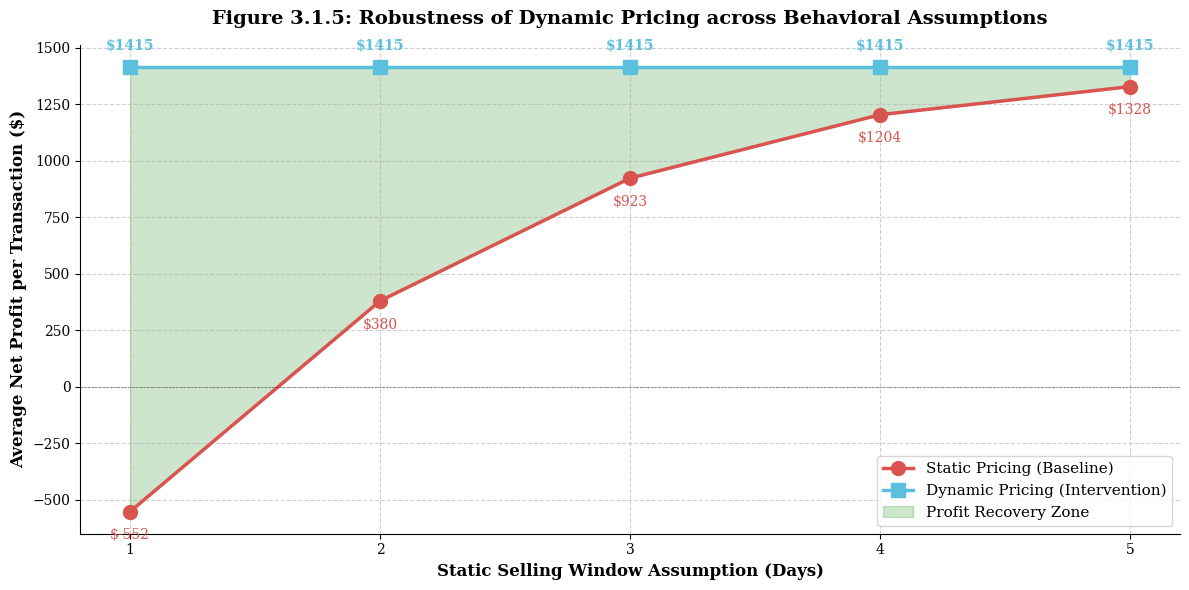

In [24]:
# ==========================================
# SECTION 3.1.5 (OPTION A): LINE CHART ROBUSTNESS ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. DEFINE PARAMETER GRID
selling_windows = [1, 2, 3, 4, 5]

# 2. FIXED DYNAMIC PARAMETERS (from main simulation)
FIXED_ELASTICITY = 3.0
FIXED_TIER1_THRESHOLD = 0.50
FIXED_TIER2_THRESHOLD = 0.20
FIXED_TIER1_DISCOUNT = 0.20
FIXED_TIER2_DISCOUNT = 0.40

# 3. INITIALIZE RESULT ARRAYS
static_profits = []
dynamic_profits = []
static_wastes = []
dynamic_wastes = []

# 4. ITERATE OVER SELLING WINDOWS
print("--- EXECUTING ROBUSTNESS ANALYSIS ---")

for window in selling_windows:
    # Static scenario with variable selling window
    temp_static = df_baseline.copy()
    temp_static['effective_days'] = np.minimum(
        temp_static['days_remaining_at_purchase'], window
    )
    temp_static['total_demand'] = temp_static['daily_demand'] * temp_static['effective_days']
    temp_static['units_sold'] = np.minimum(
        temp_static['initial_quantity'], temp_static['total_demand']
    )
    temp_static['units_wasted'] = temp_static['initial_quantity'] - temp_static['units_sold']
    temp_static['waste_pct'] = (temp_static['units_wasted'] / temp_static['initial_quantity']) * 100
    temp_static['revenue'] = temp_static['units_sold'] * temp_static['base_price']
    temp_static['sunk_cost'] = temp_static['initial_quantity'] * temp_static['cost_price']
    temp_static['net_profit'] = temp_static['revenue'] - temp_static['sunk_cost']

    static_profits.append(temp_static['net_profit'].mean())
    static_wastes.append(temp_static['waste_pct'].mean())

    # Dynamic scenario remains unchanged (full shelf life remaining)
    temp_dyn = df_filtered.drop(df_baseline.index).copy()
    temp_dyn['lifecycle_ratio'] = (
        temp_dyn['days_remaining_at_purchase'] / temp_dyn['shelf_life_days']
    )

    def assign_discount(ratio):
        if ratio <= FIXED_TIER2_THRESHOLD:
            return FIXED_TIER2_DISCOUNT
        elif ratio <= FIXED_TIER1_THRESHOLD:
            return FIXED_TIER1_DISCOUNT
        else:
            return 0.00

    temp_dyn['discount_pct'] = temp_dyn['lifecycle_ratio'].apply(assign_discount)
    temp_dyn['simulated_price'] = temp_dyn['base_price'] * (1 - temp_dyn['discount_pct'])
    temp_dyn['demand_multiplier'] = 1 + (temp_dyn['discount_pct'] * FIXED_ELASTICITY)
    temp_dyn['effective_days'] = temp_dyn['days_remaining_at_purchase']
    temp_dyn['total_demand'] = (
        temp_dyn['daily_demand']
        * temp_dyn['effective_days']
        * temp_dyn['demand_multiplier']
    )
    temp_dyn['units_sold'] = np.minimum(
        temp_dyn['initial_quantity'], temp_dyn['total_demand']
    )
    temp_dyn['units_wasted'] = temp_dyn['initial_quantity'] - temp_dyn['units_sold']
    temp_dyn['waste_pct'] = (temp_dyn['units_wasted'] / temp_dyn['initial_quantity']) * 100
    temp_dyn['revenue'] = temp_dyn['units_sold'] * temp_dyn['simulated_price']
    temp_dyn['sunk_cost'] = temp_dyn['initial_quantity'] * temp_dyn['cost_price']
    temp_dyn['net_profit'] = temp_dyn['revenue'] - temp_dyn['sunk_cost']

    dynamic_profits.append(temp_dyn['net_profit'].mean())
    dynamic_wastes.append(temp_dyn['waste_pct'].mean())

# 5. OUTPUT RESULTS TABLE
results_df = pd.DataFrame({
    'Static Selling Window (Days)': selling_windows,
    'Static Profit ($)': static_profits,
    'Dynamic Profit ($)': dynamic_profits,
    'Profit Delta ($)': [d - s for s, d in zip(static_profits, dynamic_profits)],
    'Static Waste (%)': static_wastes,
    'Dynamic Waste (%)': dynamic_wastes
})

print("\n--- ROBUSTNESS ANALYSIS RESULTS ---")
print(results_df.round(2).to_string(index=False))

# 6. LINE CHART VISUALIZATION
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(selling_windows, static_profits,
        marker='o', markersize=10, linewidth=2.5,
        color='#d9534f', label='Static Pricing (Baseline)')
ax.plot(selling_windows, dynamic_profits,
        marker='s', markersize=10, linewidth=2.5,
        color='#5bc0de', label='Dynamic Pricing (Intervention)')

# Fill the gap between the two lines to highlight Profit Recovery
ax.fill_between(selling_windows, static_profits, dynamic_profits,
                alpha=0.2, color='green', label='Profit Recovery Zone')

# Add value labels
for i, (sw, sp, dp) in enumerate(zip(selling_windows, static_profits, dynamic_profits)):
    ax.annotate(f'${sp:.0f}', xy=(sw, sp), xytext=(0, -20),
                textcoords='offset points', ha='center', fontsize=10, color='#d9534f')
    ax.annotate(f'${dp:.0f}', xy=(sw, dp), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=10,
                color='#5bc0de', fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_xlabel('Static Selling Window Assumption (Days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Net Profit per Transaction ($)', fontsize=12, fontweight='bold')
ax.set_title('Figure 3.1.5: Robustness of Dynamic Pricing across Behavioral Assumptions',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(selling_windows)
ax.legend(loc='best', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Figure_3_1_5_A_LineChart.png', dpi=300, bbox_inches='tight')
plt.show()

--- COMPUTING EXTENDED STATIC PROFIT CURVE ---

--- BREAK-EVEN POINT NOT FOUND IN RANGE ---
Static Pricing cannot reach Dynamic Pricing performance within 15-day window

--- PROFIT GAP TABLE ---
 Static Selling Window (Days)  Static Profit ($)  Dynamic Profit ($)  Gap ($)
                          1.0            -552.29             1414.88  1967.17
                          1.5             -40.61             1414.88  1455.49
                          2.0             380.02             1414.88  1034.86
                          2.5             689.55             1414.88   725.33
                          3.0             923.08             1414.88   491.80
                          3.5            1088.00             1414.88   326.88
                          4.0            1203.96             1414.88   210.92
                          4.5            1277.73             1414.88   137.15
                          5.0            1328.36             1414.88    86.52
                         

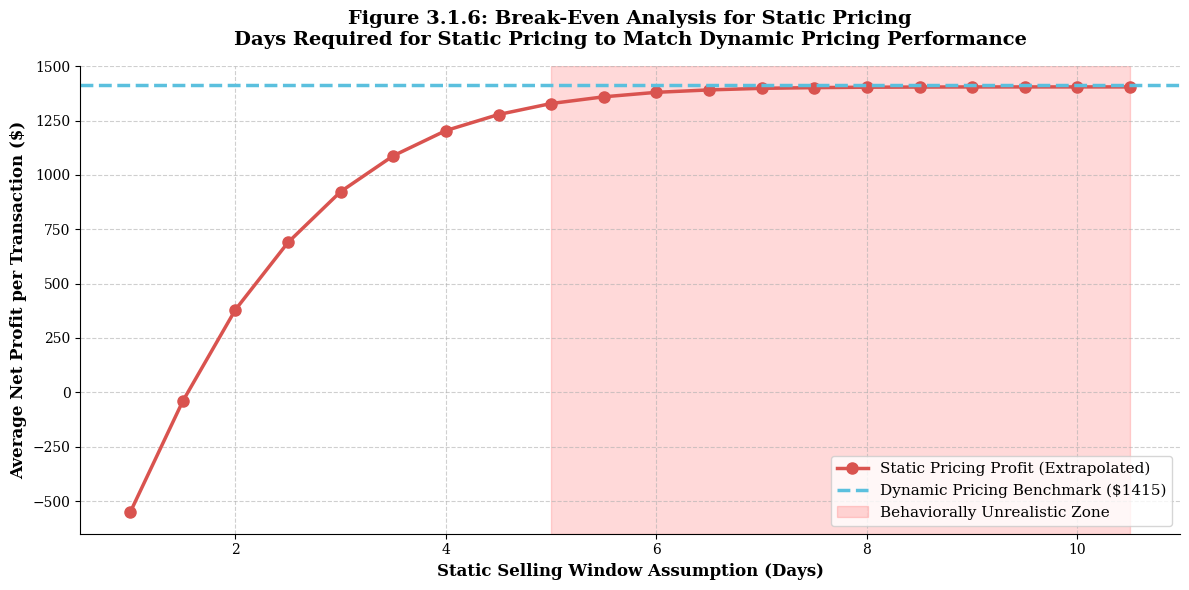

In [25]:
# ==========================================
# SECTION 3.1.5.2: BREAK-EVEN ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# 1. EXTEND THE STATIC SELLING WINDOW RANGE TO IDENTIFY BREAK-EVEN POINT
extended_windows = np.arange(1, 11, 0.5)
extended_static_profits = []

# Fixed Dynamic Profit benchmark (from main simulation)
DYNAMIC_PROFIT_BENCHMARK = 1414.88

print("--- COMPUTING EXTENDED STATIC PROFIT CURVE ---")
for window in extended_windows:
    temp_static = df_baseline.copy()
    temp_static['effective_days'] = np.minimum(
        temp_static['days_remaining_at_purchase'], window
    )
    temp_static['total_demand'] = temp_static['daily_demand'] * temp_static['effective_days']
    temp_static['units_sold'] = np.minimum(
        temp_static['initial_quantity'], temp_static['total_demand']
    )
    temp_static['revenue'] = temp_static['units_sold'] * temp_static['base_price']
    temp_static['sunk_cost'] = temp_static['initial_quantity'] * temp_static['cost_price']
    temp_static['net_profit'] = temp_static['revenue'] - temp_static['sunk_cost']
    extended_static_profits.append(temp_static['net_profit'].mean())

# 2. IDENTIFY BREAK-EVEN WINDOW USING INTERPOLATION
extended_static_array = np.array(extended_static_profits)
gap_function = interp1d(extended_windows, extended_static_array - DYNAMIC_PROFIT_BENCHMARK,
                        kind='cubic', fill_value="extrapolate")

# Find where Static profit equals Dynamic profit
try:
    breakeven_window = brentq(gap_function, 1, 15)
    print(f"\n--- BREAK-EVEN POINT IDENTIFIED ---")
    print(f"Static Selling Window required to match Dynamic Pricing: {breakeven_window:.2f} days")
except ValueError:
    print("\n--- BREAK-EVEN POINT NOT FOUND IN RANGE ---")
    print("Static Pricing cannot reach Dynamic Pricing performance within 15-day window")
    breakeven_window = None

# 3. CALCULATE PROFIT GAP AT KEY WINDOW VALUES
print("\n--- PROFIT GAP TABLE ---")
gap_table = pd.DataFrame({
    'Static Selling Window (Days)': extended_windows,
    'Static Profit ($)': extended_static_array,
    'Dynamic Profit ($)': [DYNAMIC_PROFIT_BENCHMARK] * len(extended_windows),
    'Gap ($)': DYNAMIC_PROFIT_BENCHMARK - extended_static_array
})
print(gap_table.round(2).to_string(index=False))

# 4. VISUALIZATION: BREAK-EVEN CURVE
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(extended_windows, extended_static_array,
        marker='o', markersize=8, linewidth=2.5, color='#d9534f',
        label='Static Pricing Profit (Extrapolated)')
ax.axhline(y=DYNAMIC_PROFIT_BENCHMARK, color='#5bc0de', linewidth=2.5,
           linestyle='--', label=f'Dynamic Pricing Benchmark (${DYNAMIC_PROFIT_BENCHMARK:.0f})')

if breakeven_window is not None:
    ax.axvline(x=breakeven_window, color='green', linewidth=2, linestyle=':',
               label=f'Break-Even Window ({breakeven_window:.2f} days)')
    ax.plot(breakeven_window, DYNAMIC_PROFIT_BENCHMARK, 'go', markersize=15)
    ax.annotate(f'  Break-Even Point\n  ({breakeven_window:.2f} days, ${DYNAMIC_PROFIT_BENCHMARK:.0f})',
                xy=(breakeven_window, DYNAMIC_PROFIT_BENCHMARK),
                xytext=(breakeven_window + 0.5, DYNAMIC_PROFIT_BENCHMARK - 300),
                fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green'))

# Shade the unrealistic region
ax.axvspan(5, extended_windows.max(), alpha=0.15, color='red',
           label='Behaviorally Unrealistic Zone')

ax.set_xlabel('Static Selling Window Assumption (Days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Net Profit per Transaction ($)', fontsize=12, fontweight='bold')
ax.set_title('Figure 3.1.6: Break-Even Analysis for Static Pricing\n'
             'Days Required for Static Pricing to Match Dynamic Pricing Performance',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.savefig('Figure_3_1_6_BreakEven.png', dpi=300, bbox_inches='tight')
plt.show()

--- EXECUTING MODEL ASSUMPTION SENSITIVITY ---
Total configurations evaluated: 48

--- AVERAGE NET PROFIT MATRIX ($) ---
Window Extension Multiplier     0.0     0.2      0.4      0.6      0.8      1.0
Price Elasticity                                                               
1.5                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
2.0                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
2.5                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
3.0                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
3.5                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
4.0                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
4.5                          412.98  791.81  1104.35  1305.04  1402.87  1445.11
5.0                          412.98  791.81  1104.35  1305.04  1402.87  1445.11

--- KEY FINDINGS ---
Static Baseline Profit: $380.02
Maximum Dynamic Profit: $

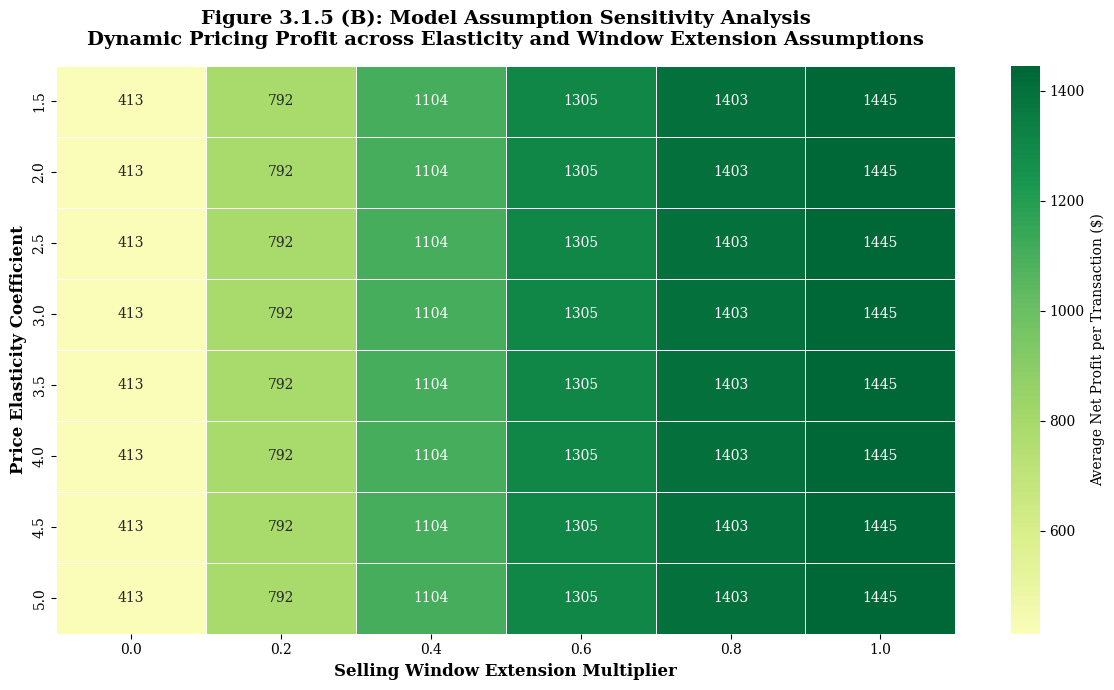

In [22]:
# ==========================================
# SECTION 3.1.5 (OPTION B): MODEL ASSUMPTION SENSITIVITY HEATMAP
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. DEFINE PARAMETER GRID FOR MODEL ASSUMPTIONS
# Price Elasticity: consumer response intensity to markdowns
elasticity_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

# Selling Window Extension Multiplier: how much markdown extends effective selling window
# 0.0 = no extension (Dynamic uses same window as Static)
# 1.0 = full extension (Dynamic uses full shelf life)
extension_multipliers = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 2. FIXED POLICY PARAMETERS
STATIC_SELLING_WINDOW = 2
FIXED_TIER1_THRESHOLD = 0.50
FIXED_TIER2_THRESHOLD = 0.20
FIXED_TIER1_DISCOUNT = 0.20
FIXED_TIER2_DISCOUNT = 0.40

# 3. INITIALIZE MATRIX
profit_matrix = np.zeros((len(elasticity_values), len(extension_multipliers)))

# 4. GRID SEARCH
print("--- EXECUTING MODEL ASSUMPTION SENSITIVITY ---")
print(f"Total configurations evaluated: {len(elasticity_values) * len(extension_multipliers)}")

for i, elasticity in enumerate(elasticity_values):
    for j, ext_mult in enumerate(extension_multipliers):
        temp_df = df_filtered.drop(df_baseline.index).copy()
        temp_df['lifecycle_ratio'] = (
            temp_df['days_remaining_at_purchase'] / temp_df['shelf_life_days']
        )

        def assign_discount(ratio):
            if ratio <= FIXED_TIER2_THRESHOLD:
                return FIXED_TIER2_DISCOUNT
            elif ratio <= FIXED_TIER1_THRESHOLD:
                return FIXED_TIER1_DISCOUNT
            else:
                return 0.00

        temp_df['discount_pct'] = temp_df['lifecycle_ratio'].apply(assign_discount)
        temp_df['simulated_price'] = temp_df['base_price'] * (1 - temp_df['discount_pct'])
        temp_df['demand_multiplier'] = 1 + (temp_df['discount_pct'] * elasticity)

        # Effective days = Static window + extension_multiplier * (remaining days - Static window)
        # This linearly interpolates between Static behavior (mult=0) and full extension (mult=1)
        temp_df['effective_days'] = (
            STATIC_SELLING_WINDOW
            + ext_mult * np.maximum(
                0,
                temp_df['days_remaining_at_purchase'] - STATIC_SELLING_WINDOW
            )
        )

        temp_df['total_demand'] = (
            temp_df['daily_demand']
            * temp_df['effective_days']
            * temp_df['demand_multiplier']
        )
        temp_df['units_sold'] = np.minimum(
            temp_df['initial_quantity'], temp_df['total_demand']
        )
        temp_df['revenue'] = temp_df['units_sold'] * temp_df['simulated_price']
        temp_df['sunk_cost'] = temp_df['initial_quantity'] * temp_df['cost_price']
        # Calculate the mean net profit and store it directly in a scalar variable
        calculated_net_profit_mean = (temp_df['revenue'] - temp_df['sunk_cost']).mean()

        # Assign the scalar mean to the profit_matrix
        profit_matrix[i, j] = calculated_net_profit_mean

# 5. CONVERT TO DATAFRAME
profit_df = pd.DataFrame(
    profit_matrix,
    index=[f'{e:.1f}' for e in elasticity_values],
    columns=[f'{m:.1f}' for m in extension_multipliers]
)
profit_df.index.name = 'Price Elasticity'
profit_df.columns.name = 'Window Extension Multiplier'

print("\n--- AVERAGE NET PROFIT MATRIX ($) ---")
print(profit_df.round(2).to_string())

# 6. IDENTIFY OPTIMAL AND STABILITY ZONE
max_profit = profit_matrix.max()
min_profit = profit_matrix.min()
static_baseline = df_baseline['net_profit'].mean()

print(f"\n--- KEY FINDINGS ---")
print(f"Static Baseline Profit: ${static_baseline:.2f}")
print(f"Maximum Dynamic Profit: ${max_profit:.2f}")
print(f"Minimum Dynamic Profit: ${min_profit:.2f}")
print(f"Worst-case Profit Recovery: ${min_profit - static_baseline:.2f}")
print(f"Best-case Profit Recovery: ${max_profit - static_baseline:.2f}")

# 7. HEATMAP VISUALIZATION
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    profit_df,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=static_baseline,
    cbar_kws={'label': 'Average Net Profit per Transaction ($)'},
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title(
    'Figure 3.1.5 (B): Model Assumption Sensitivity Analysis\n'
    'Dynamic Pricing Profit across Elasticity and Window Extension Assumptions',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Selling Window Extension Multiplier', fontsize=12, fontweight='bold')
ax.set_ylabel('Price Elasticity Coefficient', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_3_1_5_B_AssumptionHeatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("--- SO SÁNH LỢI NHUẬN TRUNG BÌNH ---")
print(f"Average Static Profit: ${results_df['Static Profit ($)'].mean():.2f}")
print(f"Average Dynamic Profit: ${results_df['Dynamic Profit ($)'].mean():.2f}")
profit_diff = results_df['Dynamic Profit ($)'].mean() - results_df['Static Profit ($)'].mean()
print(f"Difference (Dynamic - Static): ${profit_diff:.2f}")

--- BASELINE SIMULATION RESULTS (STATIC PRICING) ---
Total Scenarios Evaluated: 27,388
Average Waste Percentage: 60.89%
Total Revenue Generated: $37,734,340.62
Total Cost of Overage (Waste Cost): $30,571,969.90
Average Net Profit: $-495.62


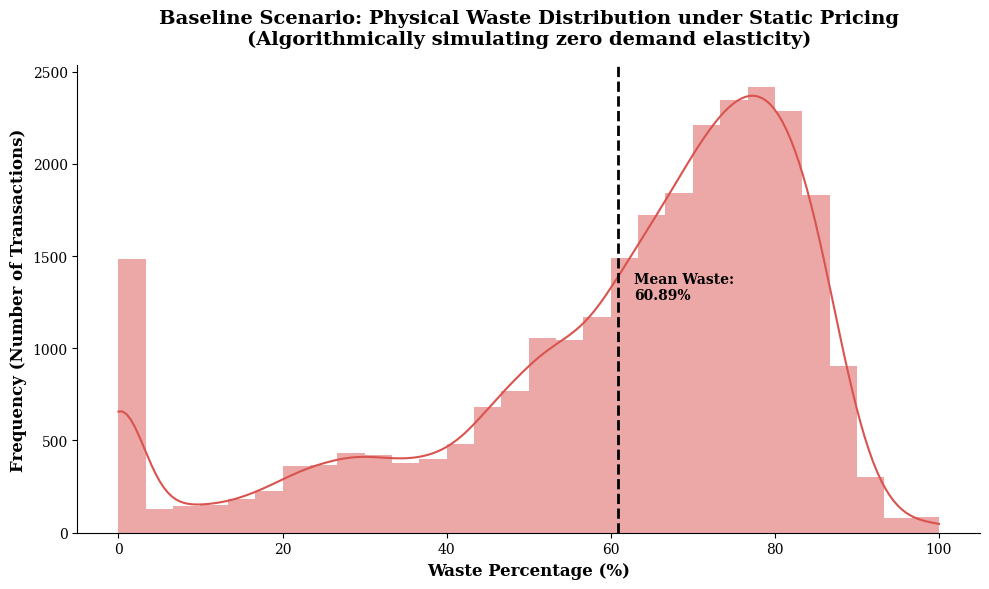

In [22]:
# ==========================================
# SECTION 3.1.2: BASELINE SCENARIO SIMULATION (STATIC PRICING)
# ==========================================
# 1. Isolate 50% of the dataset for the Baseline Control Group
df_baseline = df_filtered.sample(frac=0.5, random_state=2026).copy()

# 2. ALGORITHMIC PRICING LOGIC: STATIC PRICING
# The price remains fixed at the original base price (No markdown applied)
df_baseline['simulated_price'] = df_baseline['base_price']

# 3. KESKIN'S DETERMINISTIC INVENTORY CONSTRAINT
# Demand is not stimulated. Units sold are strictly bounded by initial inventory limit.
df_baseline['units_sold'] = np.minimum(df_baseline['initial_quantity'], df_baseline['daily_demand'])

# 4. PHYSICAL WASTE CALCULATION
df_baseline['units_wasted'] = df_baseline['initial_quantity'] - df_baseline['units_sold']
df_baseline['waste_pct'] = (df_baseline['units_wasted'] / df_baseline['initial_quantity']) * 100

# 5. FINANCIAL CALCULATIONS (SUNK COST & OVERAGE PENALTY)
df_baseline['sunk_cost'] = df_baseline['initial_quantity'] * df_baseline['cost_price']
df_baseline['revenue'] = df_baseline['units_sold'] * df_baseline['simulated_price']
df_baseline['waste_cost'] = df_baseline['units_wasted'] * df_baseline['cost_price'] # Cost of Overage
df_baseline['net_profit'] = df_baseline['revenue'] - df_baseline['sunk_cost']

# 6. OUTPUT RESULTS FOR SECTION 3.1.2
print("--- BASELINE SIMULATION RESULTS (STATIC PRICING) ---")
print(f"Total Scenarios Evaluated: {len(df_baseline):,}")
print(f"Average Waste Percentage: {df_baseline['waste_pct'].mean():.2f}%")
print(f"Total Revenue Generated: ${df_baseline['revenue'].sum():,.2f}")
print(f"Total Cost of Overage (Waste Cost): ${df_baseline['waste_cost'].sum():,.2f}")
print(f"Average Net Profit: ${df_baseline['net_profit'].mean():.2f}")

# ==========================================
# 7. VISUALIZATION: WASTE DISTRIBUTION UNDER STATIC PRICING
# ==========================================
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'

# Changed stat="density" to stat="count" so the Y-axis counts absolute frequencies (up to ~6000)
sns.histplot(df_baseline['waste_pct'], bins=30, color='#d9534f', kde=True, stat="count", linewidth=0)

plt.title("Baseline Scenario: Physical Waste Distribution under Static Pricing\n(Algorithmically simulating zero demand elasticity)",
          fontsize=14, fontweight='bold', pad=15)

# ĐÃ SỬA TÊN 2 TRỤC KHỚP VỚI TEXT TRONG LUẬN VĂN
plt.xlabel("Waste Percentage (%)", fontsize=12, fontweight='bold')
plt.ylabel("Frequency (Number of Transactions)", fontsize=12, fontweight='bold')

# Mark the mean waste percentage
mean_waste = df_baseline['waste_pct'].mean()
plt.axvline(mean_waste, color='black', linestyle='dashed', linewidth=2)

# Dynamically place the text so it perfectly aligns with the count scale
y_max = plt.gca().get_ylim()[1]
plt.text(mean_waste + 2, y_max * 0.5, f'Mean Waste:\n{mean_waste:.2f}%', color='black', fontweight='bold')

sns.despine()
plt.tight_layout()

# Save the plot for the thesis document
plt.savefig('Figure_3_1_2_Baseline_Simulation.png', dpi=300)
plt.show()